Manuel Griseri, Daniel Badaire, UEVE, M2QF

<h1 style="text-align: center;">Prediction of the churn rate of a mobile company</h1>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import matplotlib.patches as mpatches
from scipy.stats import jarque_bera

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score, roc_auc_score)
from xgboost import XGBClassifier
import warnings
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

from sklearn.calibration import calibration_curve

## 1. Exploratory data analysis

In [4]:
# Load the dataset
df = pd.read_csv("celldata.csv")

# Print the shape of the full dataframe (rows, columns)
print(np.shape(df))

# Count and print the total number of missing values in the entire dataframe
print("Total NA cells in the dataframe:", int(df.isna().sum().sum()))

# Display the first few rows of the dataset
df.head()

(8000, 11)
Total NA cells in the dataframe: 0


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Salary,Churn
0,632,Germany,Female,50,5,107959.39,1,1,1,6985,1
1,649,France,Female,42,7,0.00,2,0,1,22974,0
2,595,France,Male,29,6,150685.79,1,1,0,87771,0
3,653,Spain,Male,35,6,116662.96,2,1,1,23864,0
4,559,Spain,Female,40,7,144470.77,1,1,1,18918,0


In [5]:
# Transform categorical variables
# Gender: map to numeric (Female = 0, Male = 1)
df['Gender_num'] = df['Gender'].map({'Female': 0, 'Male': 1})

# Geography: one-hot encode, and convert to int (not boolean)
geo_dummies = pd.get_dummies(df['Geography'], prefix='Geo').astype(int)

# Ensure HasCrCard and IsActiveMember are numeric (0/1)
df['HasCrCard'] = df['HasCrCard'].astype(int)
df['IsActiveMember'] = df['IsActiveMember'].astype(int)

# Convert any remaining boolean column into integers
df = df.apply(lambda col: col.astype(int) if col.dtype == 'bool' else col)

# Concatenate geographic dummies
df = pd.concat([df, geo_dummies], axis=1)

# Define numeric feature set
numeric_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember',
    'Salary',
    'Gender_num'
]

numeric_features += list(geo_dummies.columns)

Xnum = df[numeric_features]
Xcols = list(Xnum.columns)

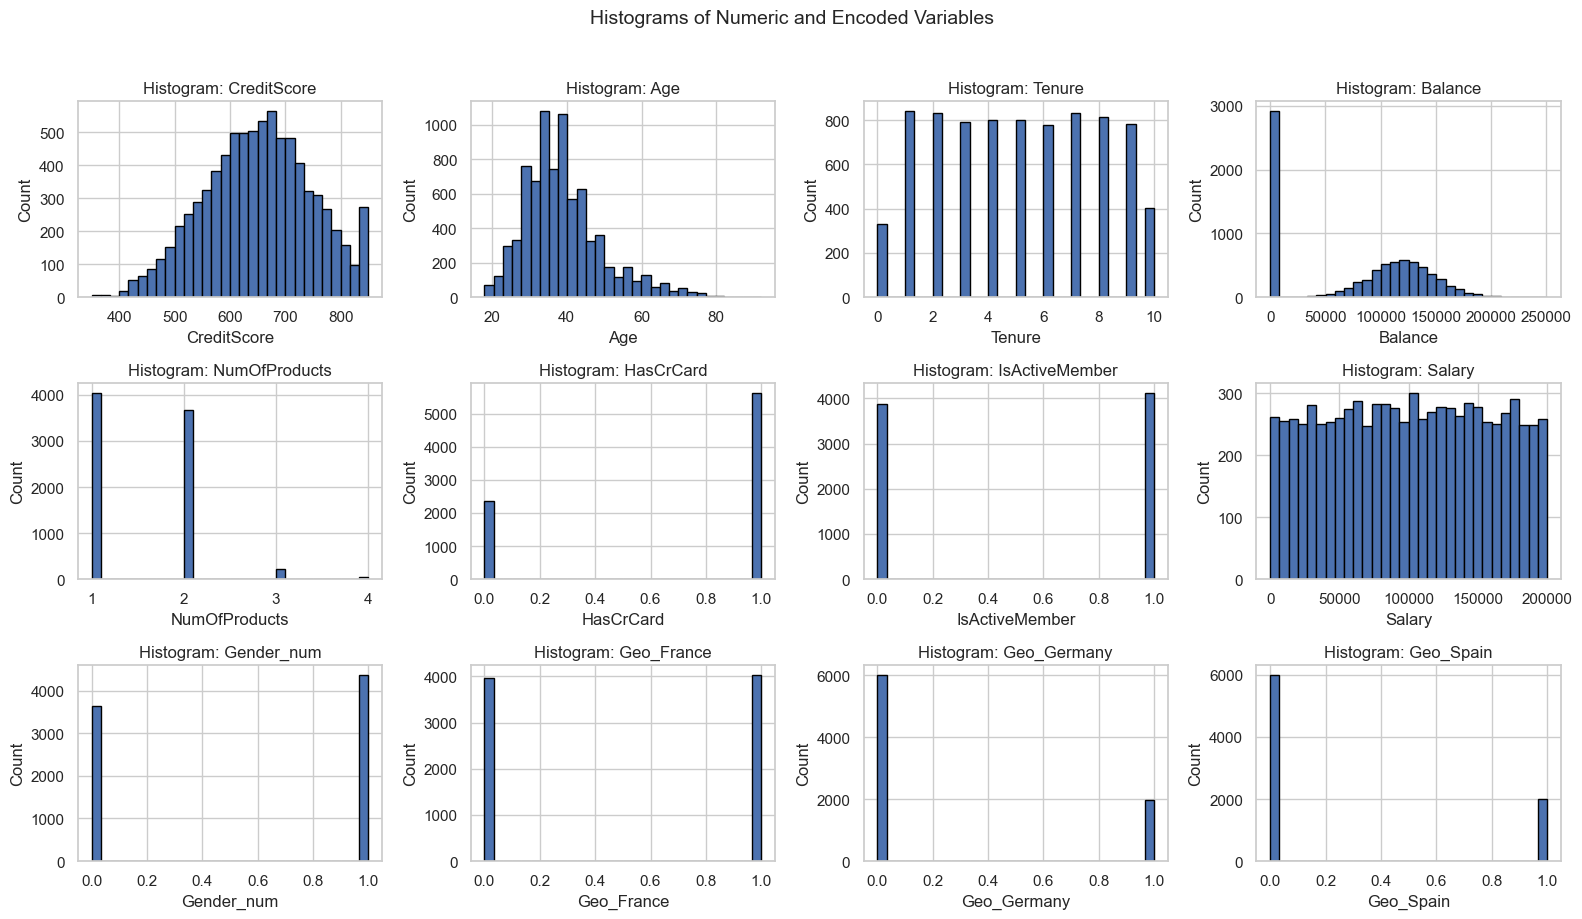

In [6]:
# Histograms (flexible grid)
sns.set(style='whitegrid', context='notebook')

n_cols = 4
n_plots = len(Xcols)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = np.array(axes).ravel()

for ax, col in zip(axes, Xcols):
    ax.hist(df[col].dropna(), bins=30, edgecolor='black')
    ax.set_title(f'Histogram: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

# Disable empty axes
for ax in axes[n_plots:]:
    ax.axis('off')

fig.suptitle('Histograms of Numeric and Encoded Variables', y=1.02, fontsize=14)
fig.tight_layout()
# plt.savefig("Histogram.png", dpi=300, bbox_inches='tight')
plt.show()

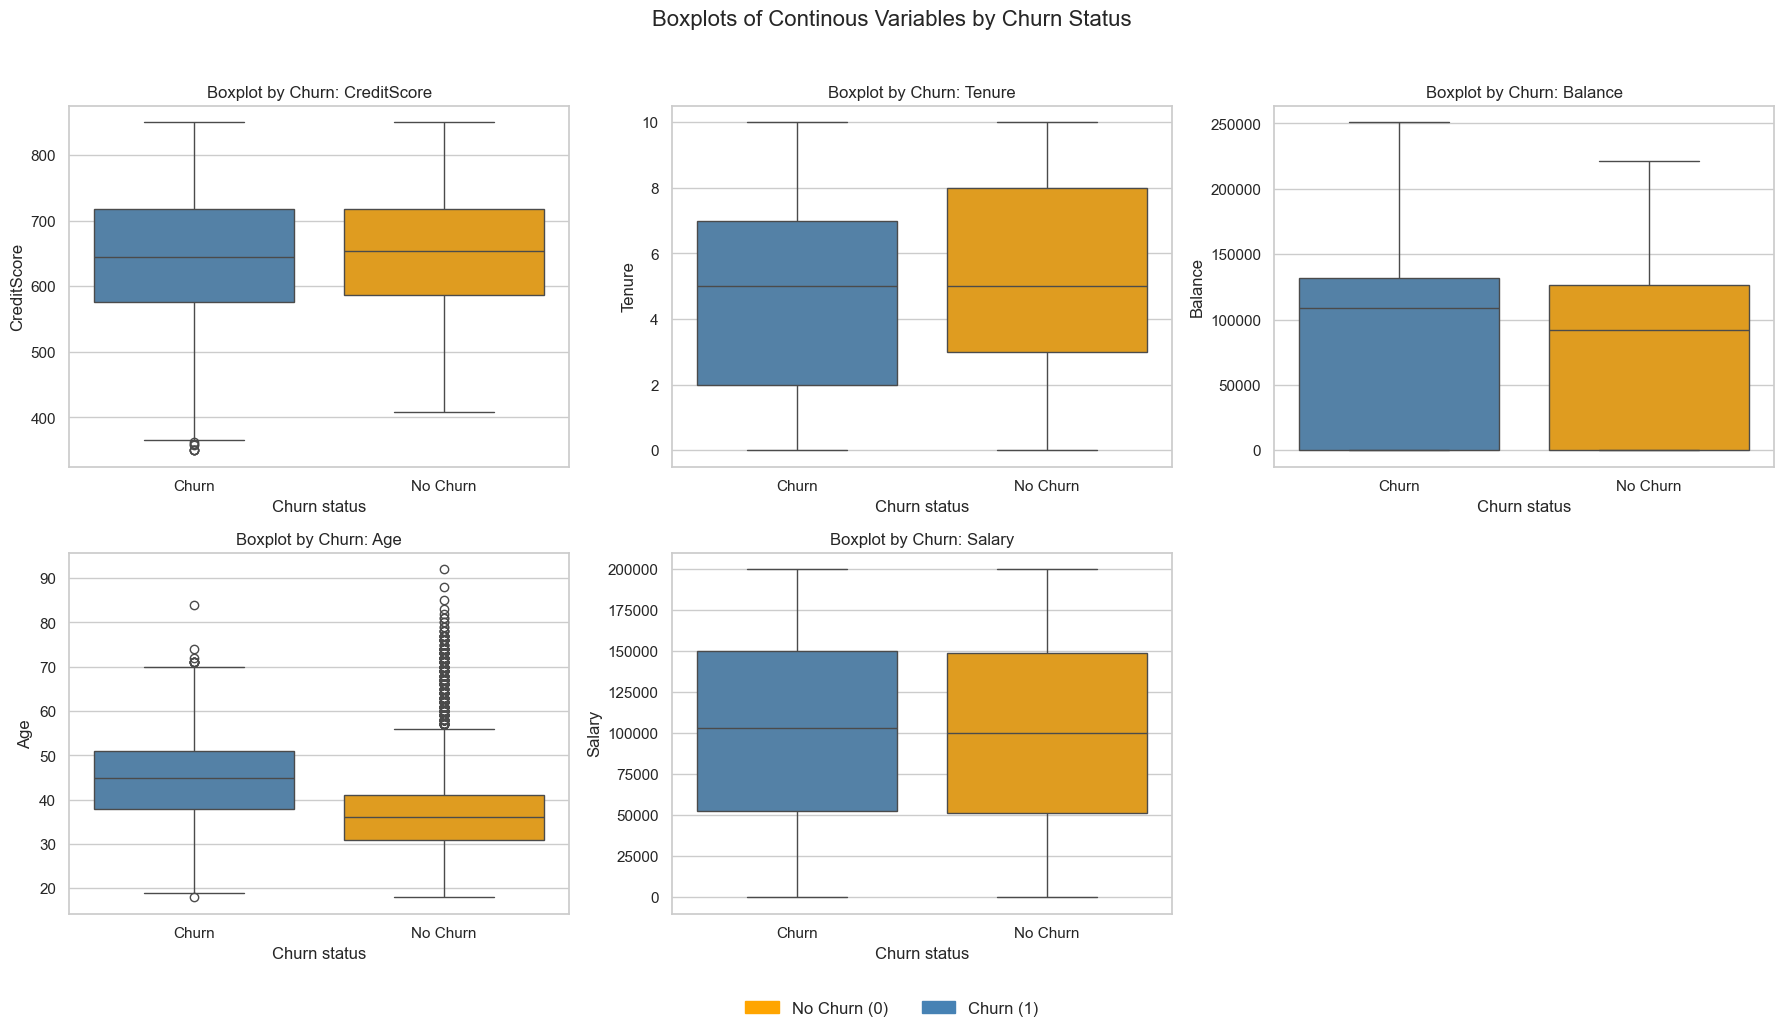

In [7]:
# Select only continous variables 
quantitatives = ['CreditScore', 'Tenure', 'Balance', 'Age', 'Salary']

# Create a label for the Churn variable (0 → No Churn, 1 → Churn)
df['Churn_label'] = df['Churn'].map({0: 'No Churn', 1: 'Churn'})

# Prepare figure with enough rows and columns (5 variables → 2×3 grid)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

# Define colors for classes
palette = {"No Churn": "orange", "Churn": "steelblue"}

# Create one boxplot per selected variable
for ax, col in zip(axes, quantitatives):
    sns.boxplot(
        data=df,
        x='Churn_label',
        y=col,
        hue='Churn_label',
        palette=palette,
        ax=ax,
        legend=False
    )
    ax.set_title(f'Boxplot by Churn: {col}')
    ax.set_xlabel('Churn status')
    ax.set_ylabel(col)

# Turn off unused axes (last one, since 5 plots in a 2×3 grid)
for ax in axes[len(quantitatives):]:
    ax.axis('off')

# Custom legend
orange_patch = mpatches.Patch(color='orange', label='No Churn (0)')
blue_patch = mpatches.Patch(color='steelblue', label='Churn (1)')

fig.legend(handles=[orange_patch, blue_patch],
           loc='lower center', ncol=2, fontsize=12, frameon=False)

# Global title
fig.suptitle('Boxplots of Continous Variables by Churn Status', y=1.02, fontsize=16)

# Adjust spacing
fig.tight_layout(rect=[0, 0.05, 1, 1])

# Display plot
# plt.savefig("Boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

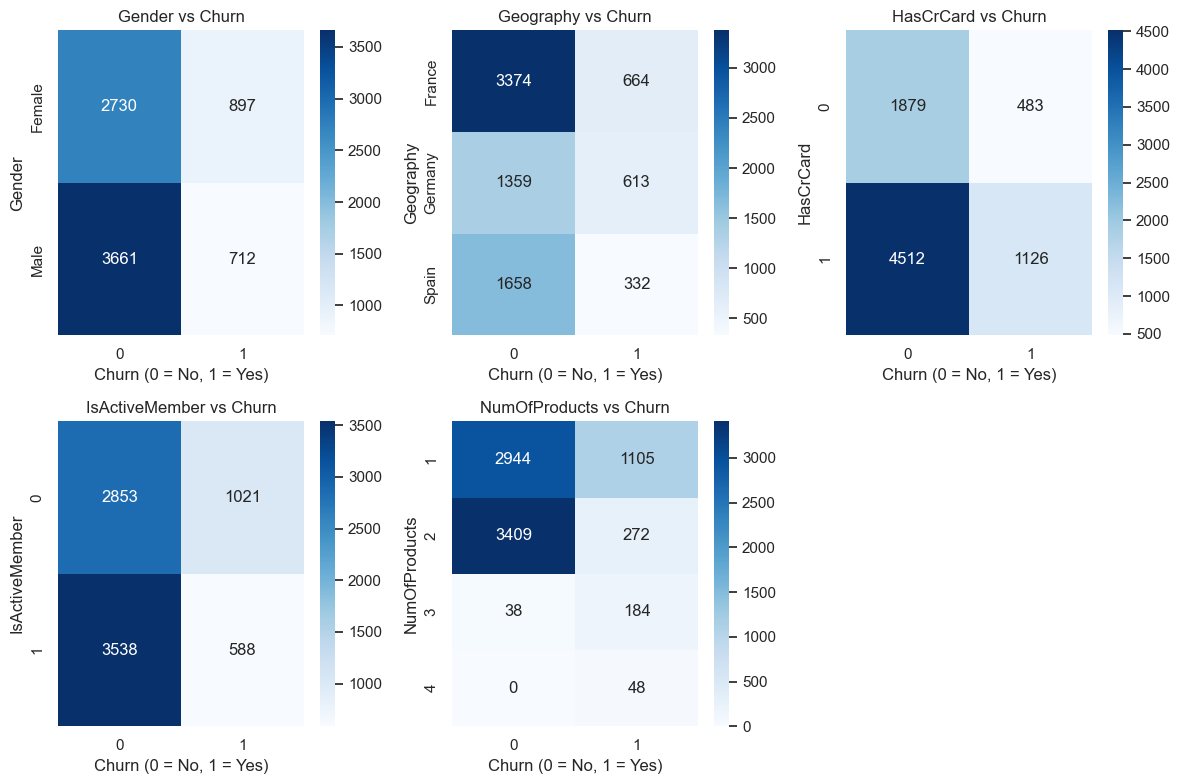

In [8]:
# Categorical variables
cat_cols = ['Gender', 'Geography', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']
df[cat_cols] = df[cat_cols].astype('category')

# Target
y = df['Churn']

# Confusion matrix 
cat_vars = cat_cols 

n_cols = 3
n_vars = len(cat_vars)
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()  

for i, col in enumerate(cat_vars):
    ax = axes[i]
    cm = pd.crosstab(df[col], y)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{col} vs Churn')
    ax.set_xlabel('Churn (0 = No, 1 = Yes)')
    ax.set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
# plt.savefig("Confusion.png", dpi=300, bbox_inches='tight')
plt.show()

Those who purchase more banking products pay more attention to their finances, so they tend to be more active and to churn more. Customers who purchase two products don’t really care, and those who purchase only one also but a little less, probably because they have lower income.

In [10]:
# List to store results
results = []

for col in quantitatives:
    for churn_class in [0, 1]:
        # Subset data for each churn class
        data = df[df['Churn'] == churn_class][col].dropna()

        # Jarque-Bera normality test
        stat, p = jarque_bera(data)

        # Conclusion on normality
        conclusion = "Normal" if p > 0.05 else "Non-normal"

        results.append({
            "Variable": col,
            "Churn": churn_class,
            "Normality": conclusion
        })

# Convert results to DataFrame
jb_table = pd.DataFrame(results).pivot(
    index="Variable",
    columns="Churn",
    values="Normality"
)

# Rename columns for clarity
jb_table.columns = ["Churn = 0", "Churn = 1"]

# Display the summary table
jb_table

,Churn = 0,Churn = 1
Variable,,
Age,Non-normal,Normal
Balance,Non-normal,Non-normal
CreditScore,Non-normal,Non-normal
Salary,Non-normal,Non-normal
Tenure,Non-normal,Non-normal


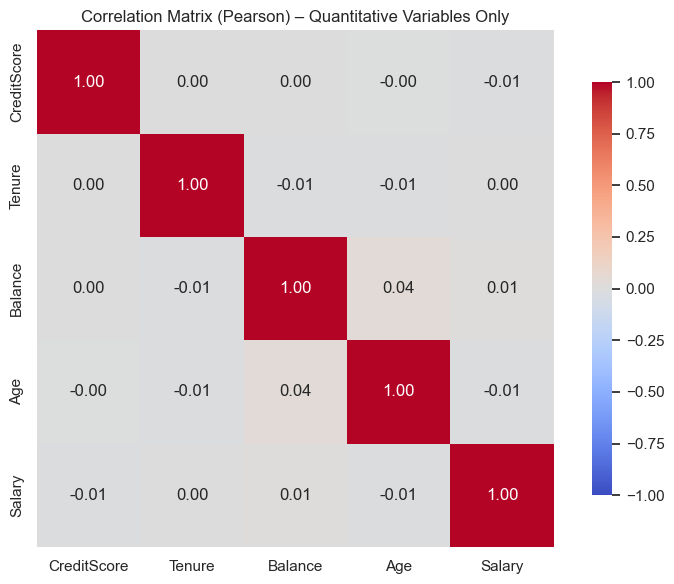

In [11]:
# Compute Pearson correlation matrix
corr = df[quantitatives].corr(method='pearson')

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    square=True, vmin=-1, vmax=1,
    cmap='coolwarm',
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Matrix (Pearson) – Quantitative Variables Only')
plt.tight_layout()
# plt.savefig("Correlation.png", dpi=300, bbox_inches='tight')
plt.show()

## 2. Supervised models

In [13]:
sns.set(style="whitegrid", context="notebook")

# Load data (again, because too many modifications have been done)
df = pd.read_csv("celldata.csv")

# Force HasCrCard and IsActiveMember as categorical
df["HasCrCard"] = df["HasCrCard"].astype("category")
df["IsActiveMember"] = df["IsActiveMember"].astype("category")

y = df["Churn"]
X = df.drop(columns=["Churn"])

# Auto-detect columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'Salary']
Categorical features: ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']


In [14]:
# Preprocessing: standardize numerics, one-hot encode categoricals
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,   # Same proportion of churn in train and test
    random_state=42
)

# Define models
ratio = (y_train == 0).sum() / (y_train == 1).sum()
models = {
    "Logistic": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "GaussianNB": GaussianNB(),
    "SVM": SVC(kernel="rbf", probability=True, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced_subsample'
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        scale_pos_weight=ratio,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=42
    )
}

# Get scores for AUC
def get_scores_for_auc(estimator, X):
    """Return scores for ROC-AUC (proba of class 1 or decision function)."""
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    elif hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    else:
        return None

In [15]:
warnings.filterwarnings("ignore")

scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "auc": "roc_auc",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_records = []
test_records = []

for name, clf in models.items():
    print(f"\n===== {name} =====")

    pipe = Pipeline([
        ("preprocess", preprocess),
        ("clf", clf)
    ])

    # Cross-validation
    cv_result = cross_validate(
        pipe,
        X_train, y_train,
        scoring=scoring,
        cv=cv,
        return_train_score=True
    )

    # Store CV scores (train + val)
    for metric in scoring.keys():
        for fold, val in enumerate(cv_result[f"train_{metric}"], start=1):
            cv_records.append({
                "model": name,
                "fold": fold,
                "set": "train",
                "metric": metric,
                "score": val
            })
        for fold, val in enumerate(cv_result[f"test_{metric}"], start=1):
            cv_records.append({
                "model": name,
                "fold": fold,
                "set": "validation",
                "metric": metric,
                "score": val
            })

    # Final fit + Test 
    pipe.fit(X_train, y_train)
    y_test_pred = pipe.predict(X_test)
    y_test_score = get_scores_for_auc(pipe, X_test)

    test_records.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_test_pred),
        "f1": f1_score(y_test, y_test_pred),
        "precision": precision_score(y_test, y_test_pred),
        "recall": recall_score(y_test, y_test_pred),
        "auc": roc_auc_score(y_test, y_test_score)
    })

cv_df = pd.DataFrame(cv_records)
test_df = pd.DataFrame(test_records)


===== Logistic =====

===== GaussianNB =====

===== SVM =====

===== KNN =====

===== RandomForest =====

===== AdaBoost =====

===== XGBoost =====


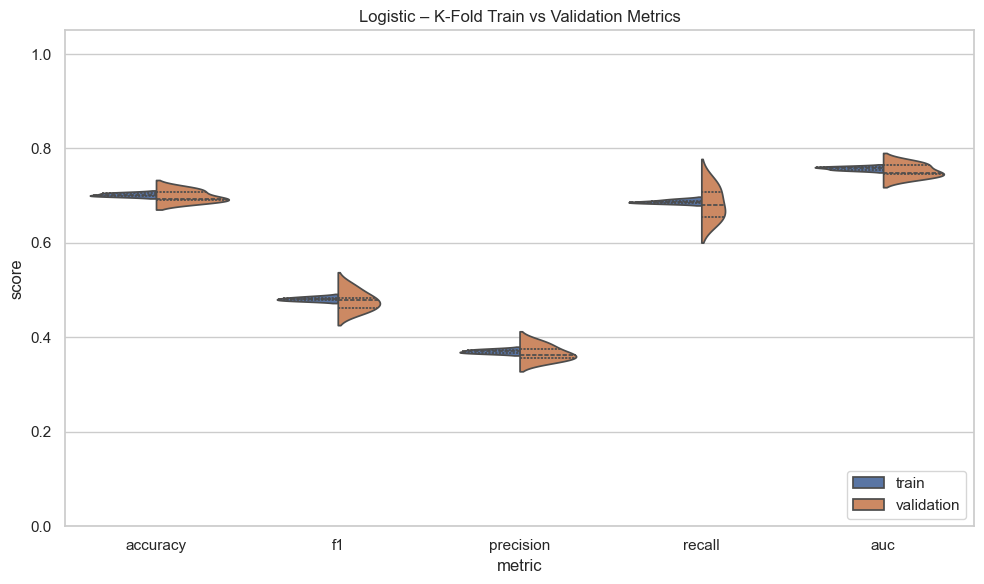

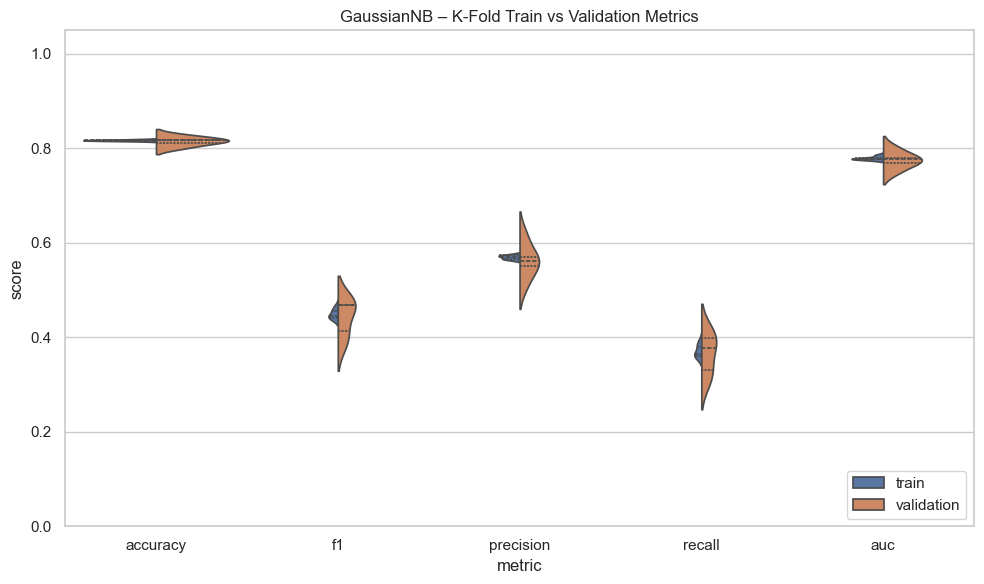

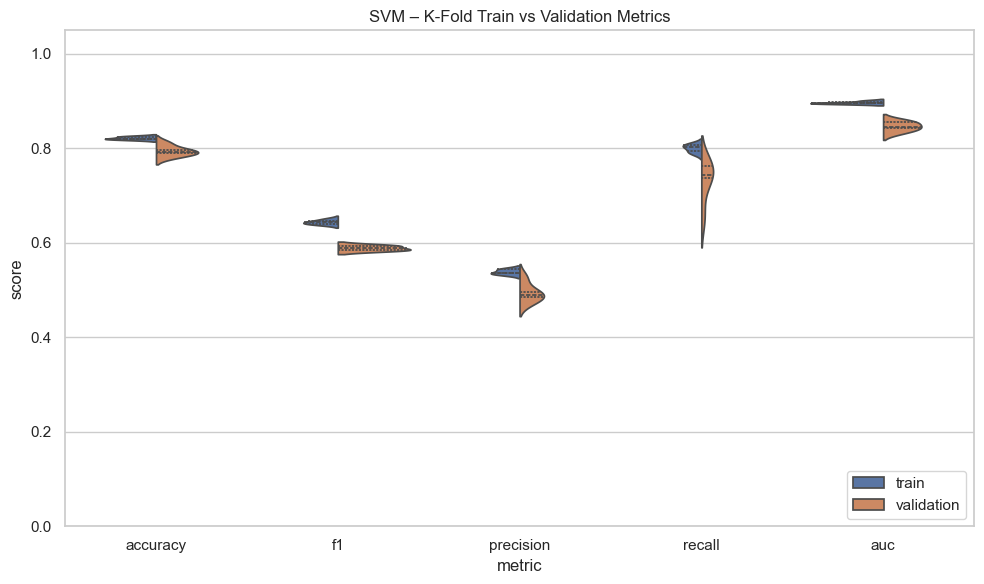

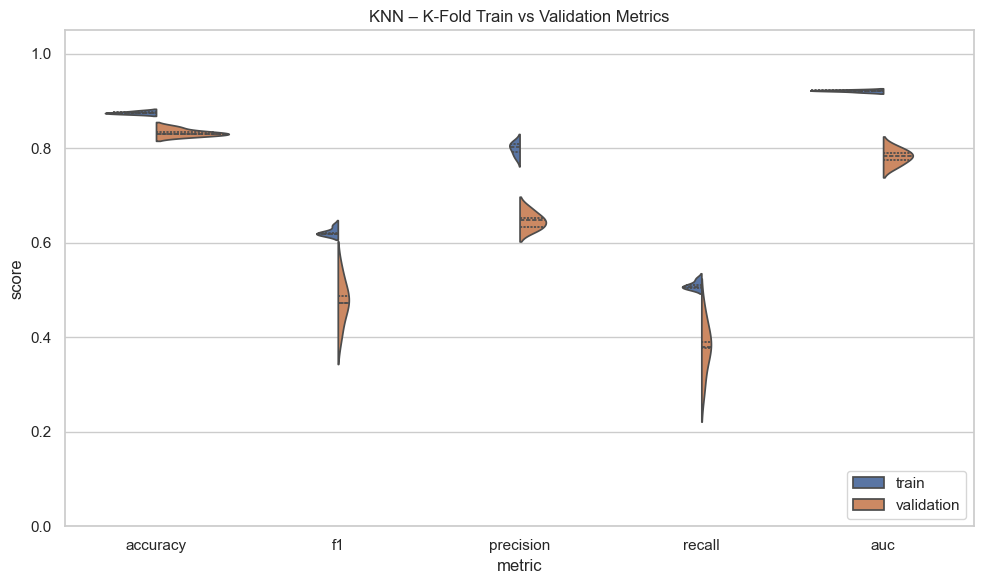

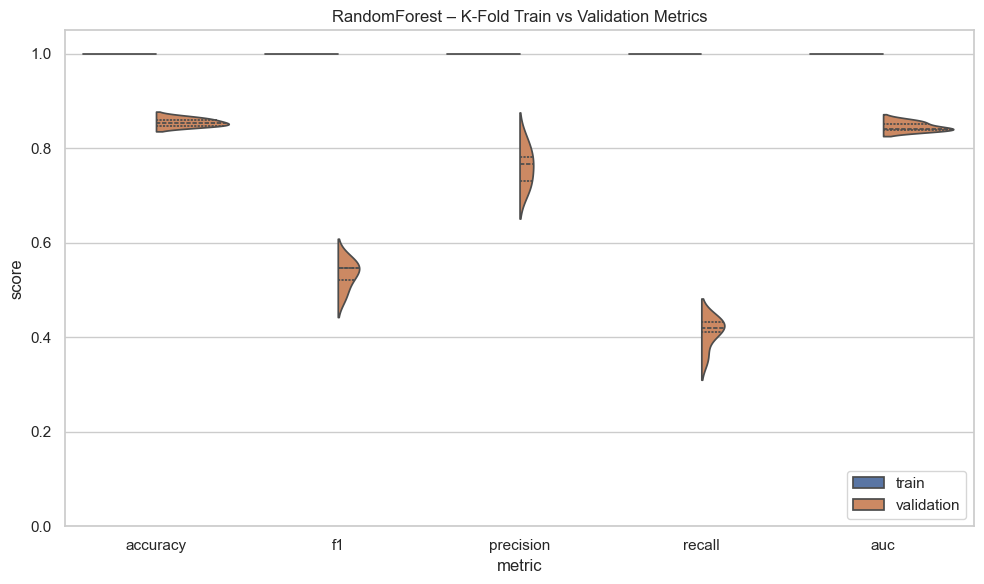

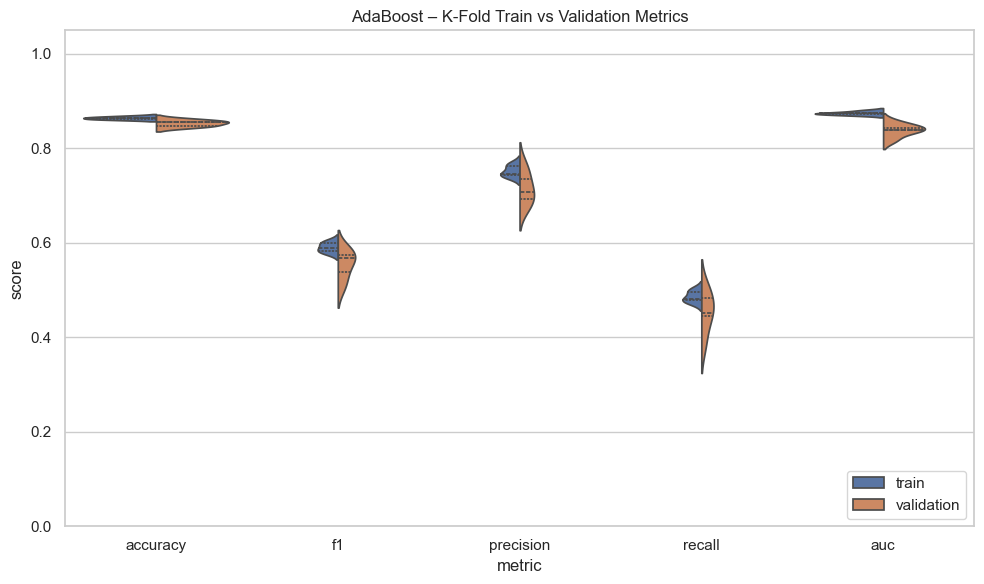

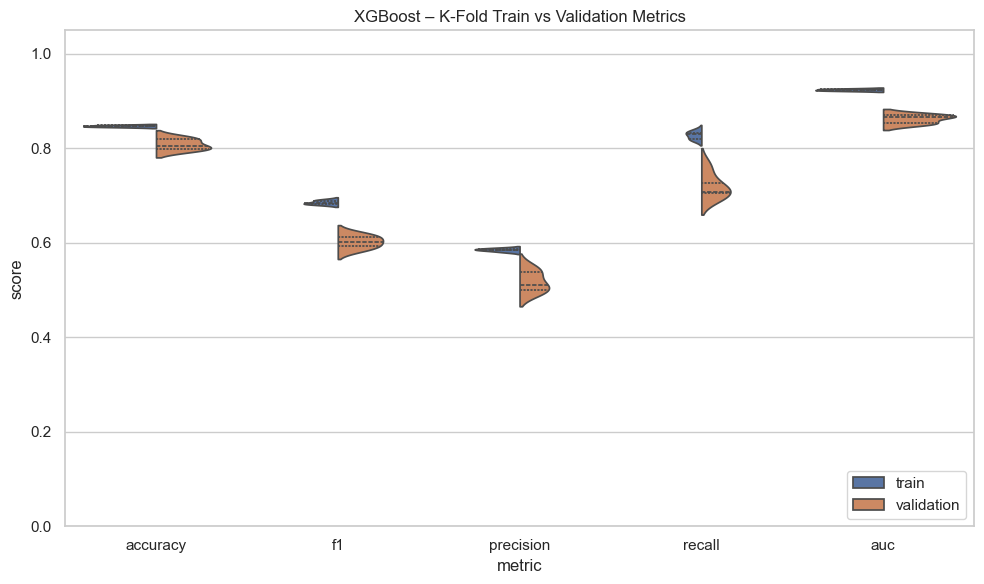

In [16]:
# Violin plots: for each model, distribution of metrics (train vs val)
for model_name in models.keys():
    subset = cv_df[cv_df["model"] == model_name]

    plt.figure(figsize=(10, 6))
    sns.violinplot(
        data=subset,
        x="metric",
        y="score",
        hue="set",
        split=True,
        inner="quartile"
    )
    plt.title(f"{model_name} – K-Fold Train vs Validation Metrics")
    plt.ylim(0, 1.05)
    plt.legend(title="", loc="lower right")
    plt.tight_layout()
    # plt.savefig(f"{model_name}_Violin.png", dpi=300, bbox_inches='tight')
    plt.show()

In [17]:
# Final test metrics summary
print("\n===== Final Test Metrics =====")
test_summary = test_df.set_index("model")
print(test_summary.round(3))


===== Final Test Metrics =====
              accuracy     f1  precision  recall    auc
model                                                  
Logistic         0.726  0.507      0.397   0.702  0.777
GaussianNB       0.821  0.451      0.587   0.366  0.785
SVM              0.789  0.587      0.485   0.742  0.847
KNN              0.838  0.497      0.663   0.398  0.779
RandomForest     0.868  0.581      0.799   0.457  0.844
AdaBoost         0.862  0.576      0.754   0.466  0.851
XGBoost          0.806  0.606      0.513   0.739  0.869


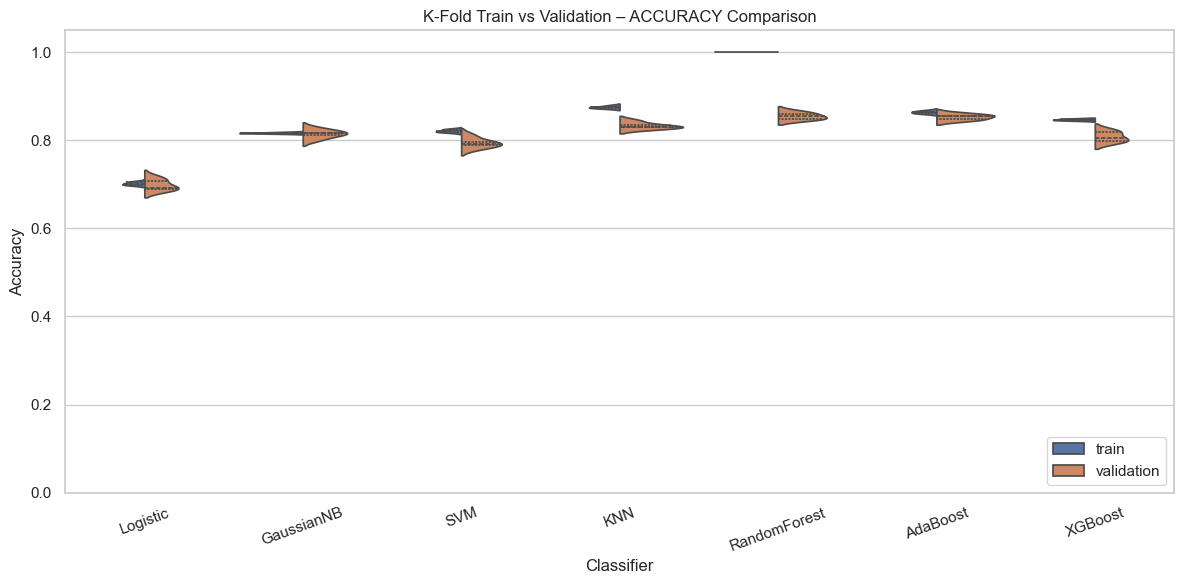

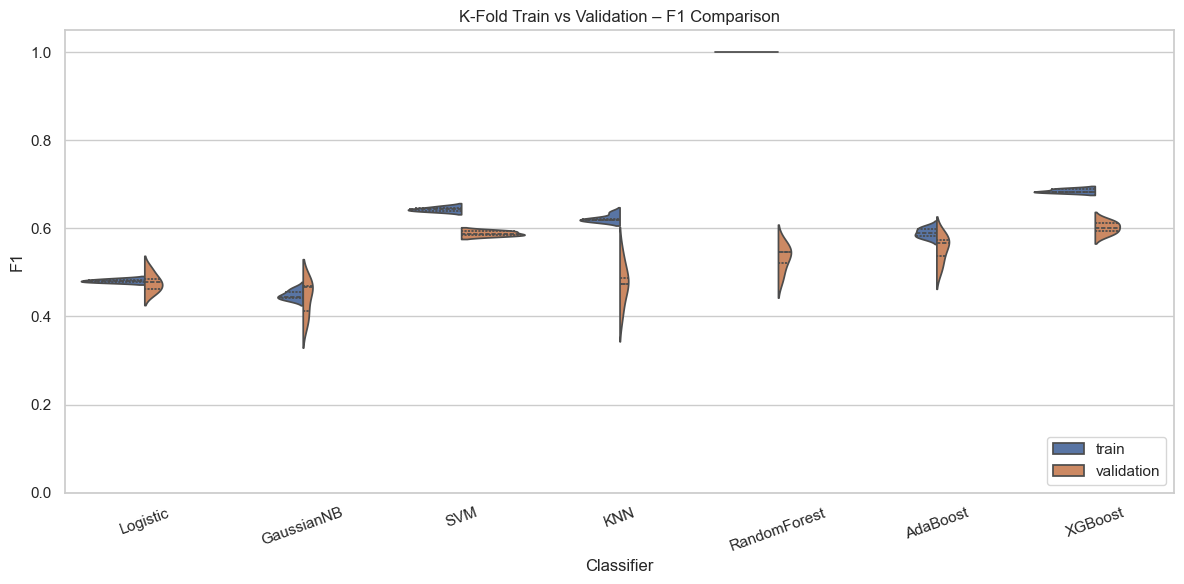

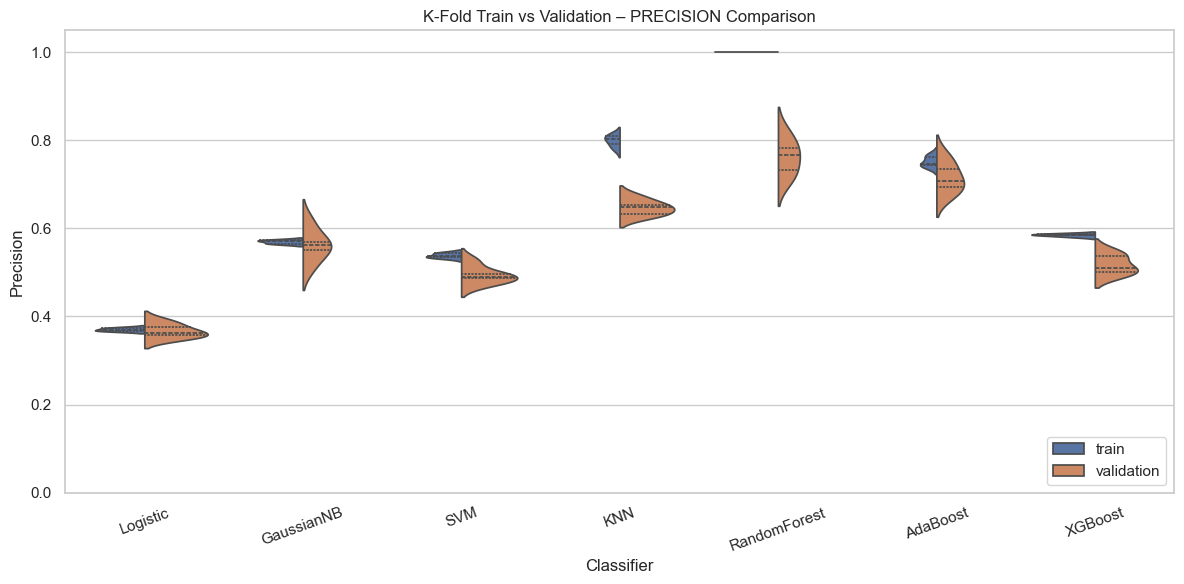

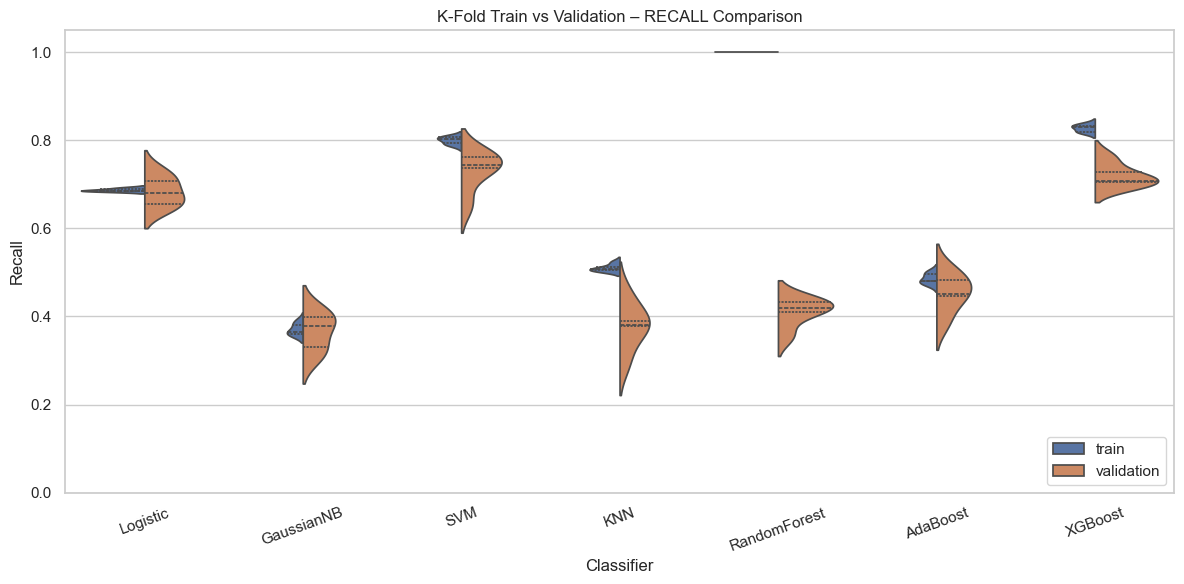

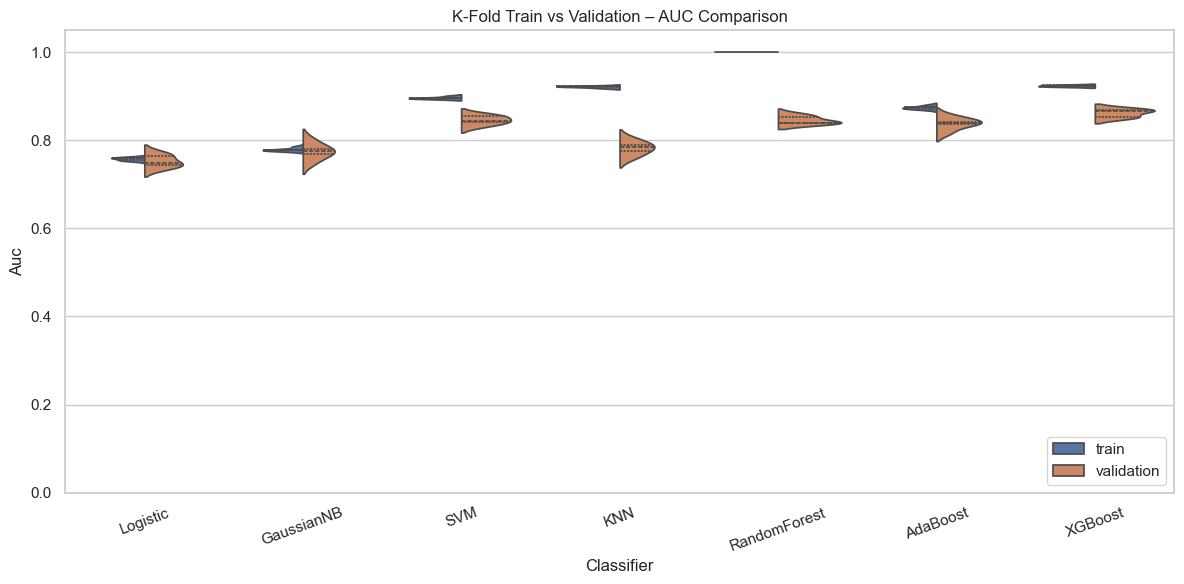

In [18]:
metrics = ["accuracy", "f1", "precision", "recall", "auc"]

for metric_name in metrics:   
    plt.figure(figsize=(12, 6))
    
    # Filter CV results for the metric
    subset = cv_df[cv_df["metric"] == metric_name]
    
    # Violin plot: models on X-axis, score on Y-axis
    sns.violinplot(
        data=subset,
        x="model",
        y="score",
        hue="set",   # Train vs validation
        split=True,
        inner="quartile"
    )
    
    plt.title(f"K-Fold Train vs Validation – {metric_name.upper()} Comparison")
    plt.ylim(0, 1.05)
    plt.xlabel("Classifier")
    plt.ylabel(metric_name.capitalize())
    plt.xticks(rotation=20)
    plt.legend(title="", loc="lower right")
    plt.tight_layout()
    # plt.savefig(f"{metric_name}_Violin.png", dpi=300, bbox_inches='tight')
    plt.show()

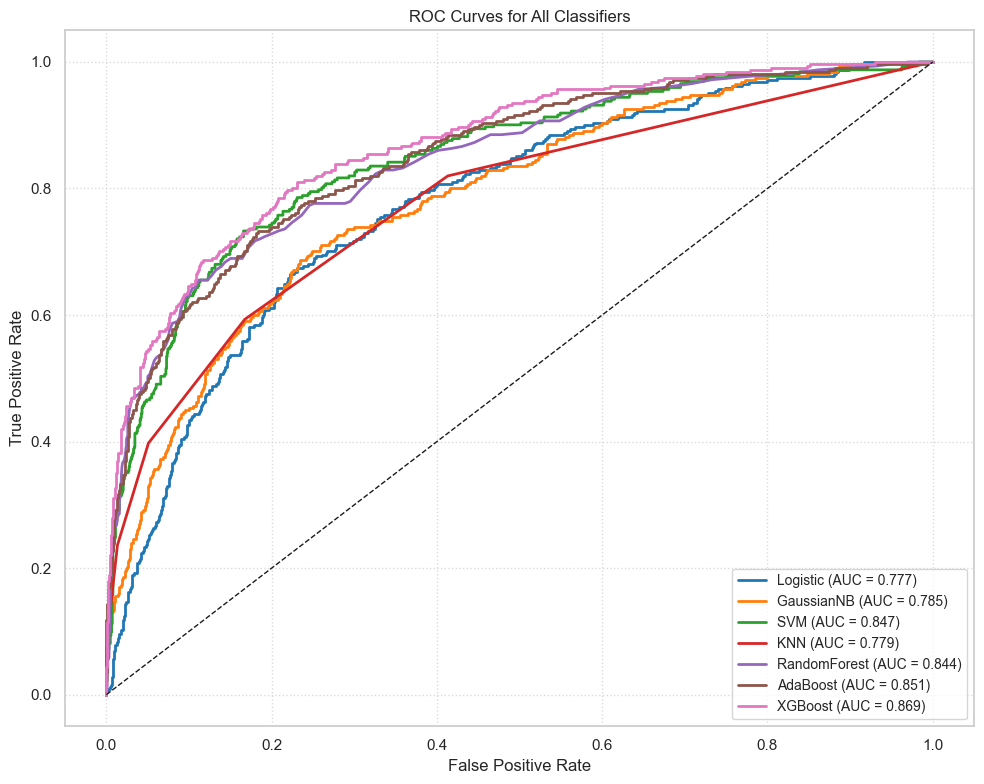

In [19]:
plt.figure(figsize=(10, 8))

# Color palette for models
palette = sns.color_palette("tab10", n_colors=len(models))

for (color, (name, clf)) in zip(palette, models.items()):
    
    # Pipeline: preprocessing + classifier
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("clf", clf)
    ])
    
    # Fit on the training data
    pipe.fit(X_train, y_train)
    
    # Prediction scores for ROC
    y_score = get_scores_for_auc(pipe, X_test)
    
    if y_score is None:
        continue
    
    # ROC coordinates
    fpr, tpr, _ = roc_curve(y_test, y_score)
    
    # AUC
    auc_value = roc_auc_score(y_test, y_score)
    
    # Plot ROC curve
    plt.plot(
        fpr, tpr,
        color=color,
        linewidth=2,
        label=f"{name} (AUC = {auc_value:.3f})"
    )

# Plot diagonal
plt.plot([0, 1], [0, 1], "k--", linewidth=1)

# Formatting
plt.title("ROC Curves for All Classifiers")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
# plt.savefig("ROC.png", dpi=300, bbox_inches='tight')
plt.show()

## 3. Hyperparameters tuning

In [21]:
def tune_model(model_name, model, param_grid, 
               X_train, y_train, preprocess,
               n_iter=30, scoring="roc_auc", cv=5, n_jobs=-1, verbose=2):
    """
    Generic hyperparameter tuning function using RandomizedSearchCV + pipeline.
    
    Parameters
    ----------
    model_name : str
        Name of the model (for printing).
    model : sklearn estimator
        The classifier to optimize.
    param_grid : dict
        Parameter search space (keys must start with 'clf__').
    X_train, y_train : DataFrame, Series
        Training data.
    preprocess : ColumnTransformer
        Preprocessing pipeline (scaling + encoding).
    n_iter : int
        Number of RandomizedSearch iterations.
    scoring : str
        Evaluation metric (default: AUC).
    cv : int
        Number of CV folds.
    n_jobs : int
        Number of CPUs.
    verbose : int
        Verbosity level.
    
    Returns
    -------
    best_model : estimator
        The tuned model wrapped in the pipeline.
    search : RandomizedSearchCV
        The full search object.
    """
    
    print(f"\n===== TUNING {model_name} =====")

    # Create pipeline: preprocess + classifier
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("clf", model)
    ])

    # Create randomized search
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs,
        random_state=42,
        verbose=verbose
    )

    # Fit search
    search.fit(X_train, y_train)

    print("Best Parameters:", search.best_params_)
    print("Best CV AUC:", search.best_score_)

    return search.best_estimator_, search

In [22]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')

log_params = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10, 50],
    "clf__penalty": ["l1", "l2"],
    "clf__solver": ["liblinear"]
}

best_logistic, search_log = tune_model(
    model_name="Logistic Regression",
    model=log_model,
    param_grid=log_params,
    X_train=X_train,
    y_train=y_train,
    preprocess=preprocess
)


===== TUNING Logistic Regression =====
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'clf__solver': 'liblinear', 'clf__penalty': 'l1', 'clf__C': 0.1}
Best CV AUC: 0.7553606011327579


In [23]:
svm_model = SVC(probability=True, class_weight='balanced')

svm_params = {
    "clf__C": [0.1, 1, 10, 50],
    "clf__gamma": ["scale", "auto"],
    "clf__kernel": ["rbf", "poly"]
}

best_svm, search_svm = tune_model(
    "SVM",
    svm_model,
    svm_params,
    X_train, y_train,
    preprocess
)


===== TUNING SVM =====
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'clf__kernel': 'poly', 'clf__gamma': 'scale', 'clf__C': 0.1}
Best CV AUC: 0.8523470636033856


In [24]:
rf_model = RandomForestClassifier(class_weight='balanced_subsample')

rf_params = {
    "clf__n_estimators": [100, 200, 500],
    "clf__max_depth": [4, 6, 8, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
}

best_rf, search_rf = tune_model(
    "Random Forest",
    rf_model,
    rf_params,
    X_train, y_train,
    preprocess
)


===== TUNING Random Forest =====
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 4, 'clf__max_depth': 8}
Best CV AUC: 0.8551911801722735


In [25]:
knn_model = KNeighborsClassifier()

knn_params = {
    "clf__n_neighbors": list(range(3, 31)),
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2]   # Manhattan or Euclidean
}

best_knn, search_knn = tune_model(
    "KNN",
    knn_model,
    knn_params,
    X_train, y_train,
    preprocess
)


===== TUNING KNN =====
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'clf__weights': 'distance', 'clf__p': 2, 'clf__n_neighbors': 28}
Best CV AUC: 0.8319308295117116


In [26]:
ada_model = AdaBoostClassifier()

ada_params = {
    "clf__n_estimators": [50, 100, 200, 500],
    "clf__learning_rate": [0.01, 0.05, 0.1, 1],
}

best_ada, search_ada = tune_model(
    "AdaBoost",
    ada_model,
    ada_params,
    X_train, y_train,
    preprocess
)


===== TUNING AdaBoost =====
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'clf__n_estimators': 200, 'clf__learning_rate': 0.1}
Best CV AUC: 0.8450039995354615


In [27]:
# Define base XGBoost model
xgb_model = XGBClassifier(
    eval_metric="logloss",
    scale_pos_weight=ratio,
    use_label_encoder=False,
    random_state=42
)

# Hyperparameter search space for XGBoost
xgb_params = {
    "clf__n_estimators": [100, 200, 400],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "clf__max_depth": [3, 4, 5, 6],
    "clf__subsample": [0.6, 0.8, 1.0],
    "clf__colsample_bytree": [0.6, 0.8, 1.0],
    "clf__gamma": [0, 0.1, 0.2],
    "clf__min_child_weight": [1, 3, 5]
}

best_xgb, search_xgb = tune_model(
    model_name="XGBoost",
    model=xgb_model,
    param_grid=xgb_params,
    X_train=X_train,
    y_train=y_train,
    preprocess=preprocess,
    n_iter=30,   # Number of random combos to try
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)


===== TUNING XGBoost =====
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'clf__subsample': 0.8, 'clf__n_estimators': 200, 'clf__min_child_weight': 5, 'clf__max_depth': 3, 'clf__learning_rate': 0.05, 'clf__gamma': 0, 'clf__colsample_bytree': 0.6}
Best CV AUC: 0.8643448911074609


In [28]:
best_models = {
    "Logistic": best_logistic,
    "SVM": best_svm,
    "KNN": best_knn,
    "RandomForest": best_rf,
    "AdaBoost": best_ada,
    "XGBoost": best_xgb
}

# Final table
results_auc = []

for model_name, model in best_models.items():
    
    # AUC without tuning  
    auc_before = test_summary.loc[model_name, "auc"]
    
    # AUC after tuning
    y_pred_score = model.predict_proba(X_test)[:, 1]
    auc_after = roc_auc_score(y_test, y_pred_score)
    
    results_auc.append({
        "Model": model_name,
        "AUC Before Tuning": auc_before,
        "AUC After Tuning": auc_after
    })

auc_comparison = pd.DataFrame(results_auc)
auc_comparison = auc_comparison.sort_values("AUC After Tuning", ascending=False)

auc_comparison

,Model,AUC Before Tuning,AUC After Tuning
5,XGBoost,0.869186,0.870185
3,RandomForest,0.844183,0.853952
4,AdaBoost,0.850691,0.852913
1,SVM,0.846997,0.848041
2,KNN,0.779235,0.841287
0,Logistic,0.776616,0.776682


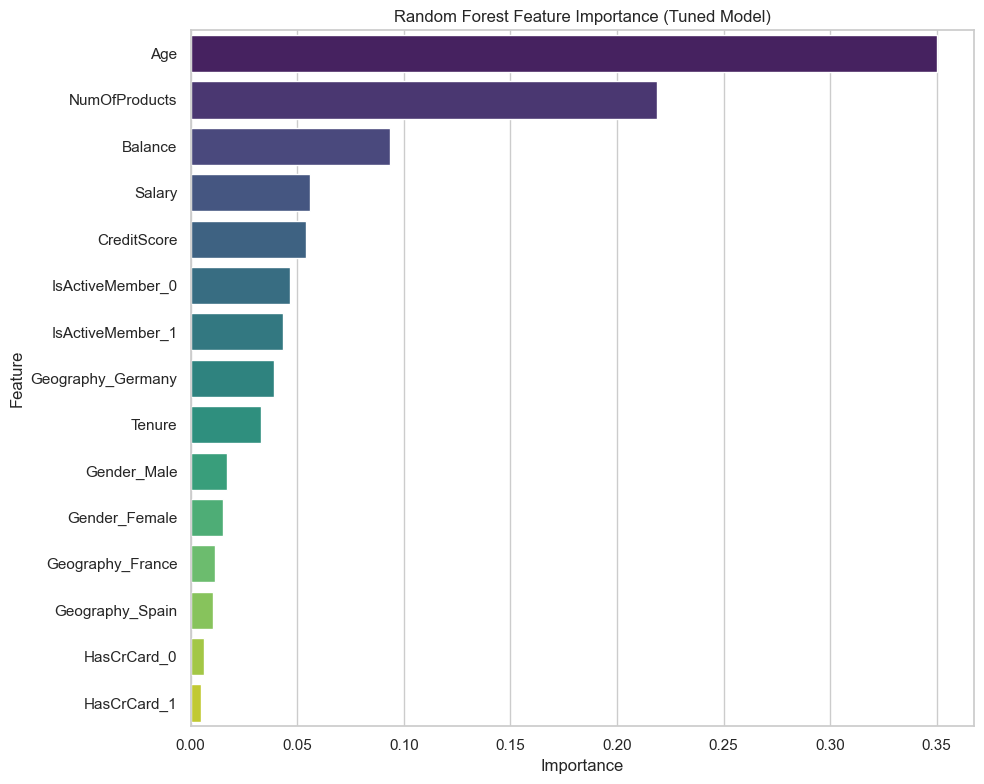

In [29]:
# Extract feature names after preprocessing
num_features = numeric_features
cat_features = preprocess.named_transformers_["cat"].get_feature_names_out(categorical_features)

all_features = list(num_features) + list(cat_features)

# Extract tuned RF inside pipeline
rf_tuned = best_rf.named_steps["clf"]

# Importance extraction
rf_tuned_importances = rf_tuned.feature_importances_

rf_tuned_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": rf_tuned_importances
}).sort_values("Importance", ascending=False)

rf_tuned_df
plt.figure(figsize=(10, 8))
sns.barplot(
    data=rf_tuned_df,
    x="Importance", 
    y="Feature",
    palette="viridis"
)
plt.title("Random Forest Feature Importance (Tuned Model)")
plt.tight_layout()
# plt.savefig("Importance.png", dpi=300, bbox_inches='tight')
plt.show()

## 4. Fairness analysis with respect to gender

In [31]:
best_row = auc_comparison.iloc[0]
best_model_name = best_row["Model"]
best_model = best_models[best_model_name]

print(f"Using advised model for fairness analysis: {best_model_name}")

Using advised model for fairness analysis: XGBoost


In [32]:
# Sensitive attribute on the test set
S_test = X_test["Gender"]

# Predictions and scores on the test set
y_pred = best_model.predict(X_test)
y_score = best_model.predict_proba(X_test)[:, 1]

# Collect everything in a single DataFrame
fair_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred,
    "score": y_score,
    "Gender": S_test.values
})

# Define groups explicitly
groups = {
    "Female": fair_df[fair_df["Gender"] == "Female"],
    "Male": fair_df[fair_df["Gender"] == "Male"]
}

def safe_rate(num, den):
    """Compute num/den with protection against division by zero."""
    return num / den if den > 0 else np.nan

# Independence (Demographic Parity)
#     F ⟂ S  → P(F = 1 | S = Female) ≈ P(F = 1 | S = Male)
ind_rows = []
for g_name, g_df in groups.items():
    # Positive prediction rate in each group
    pos_rate = g_df["y_pred"].mean()  # P(Ŷ = 1 | S = g)
    ind_rows.append({
        "Gender": g_name,
        "Positive prediction rate": pos_rate
    })

independence_df = pd.DataFrame(ind_rows)

# Absolute difference in positive rates between genders
dp_diff = (
    independence_df.loc[independence_df["Gender"] == "Male", "Positive prediction rate"].values[0]
    - independence_df.loc[independence_df["Gender"] == "Female", "Positive prediction rate"].values[0]
)

print("\n=== Independence (Demographic Parity) ===")
print(independence_df)
print(f"Demographic parity difference (Male - Female): {dp_diff:.4f}")


=== Independence (Demographic Parity) ===
   Gender  Positive prediction rate
0  Female                  0.372442
1    Male                  0.231834
Demographic parity difference (Male - Female): -0.1406


In [33]:
# Separation (Equalized Odds)
#     F ⟂ S | Y  → equal TPR and FPR across Gender
#     TPR_g = P(F = 1 | Y = 1, S = g)
#     FPR_g = P(F = 1 | Y = 0, S = g)
sep_rows = []
for g_name, g_df in groups.items():
    TP = ((g_df["y_true"] == 1) & (g_df["y_pred"] == 1)).sum()
    FN = ((g_df["y_true"] == 1) & (g_df["y_pred"] == 0)).sum()
    FP = ((g_df["y_true"] == 0) & (g_df["y_pred"] == 1)).sum()
    TN = ((g_df["y_true"] == 0) & (g_df["y_pred"] == 0)).sum()

    TPR = safe_rate(TP, TP + FN)   # True Positive Rate
    FPR = safe_rate(FP, FP + TN)   # False Positive Rate

    sep_rows.append({
        "Gender": g_name,
        "TPR": TPR,
        "FPR": FPR
    })

separation_df = pd.DataFrame(sep_rows)

tpr_gap = (
    separation_df.loc[separation_df["Gender"] == "Male", "TPR"].values[0]
    - separation_df.loc[separation_df["Gender"] == "Female", "TPR"].values[0]
)
fpr_gap = (
    separation_df.loc[separation_df["Gender"] == "Male", "FPR"].values[0]
    - separation_df.loc[separation_df["Gender"] == "Female", "FPR"].values[0]
)

print("\n=== Separation (Equalized Odds) ===")
print(separation_df)
print(f"TPR gap (Male - Female): {tpr_gap:.4f}")
print(f"FPR gap (Male - Female): {fpr_gap:.4f}")


=== Separation (Equalized Odds) ===
   Gender       TPR       FPR
0  Female  0.743316  0.245421
1    Male  0.748148  0.136612
TPR gap (Male - Female): 0.0048
FPR gap (Male - Female): -0.1088


In [34]:
# Sufficiency (Predictive parity + calibration by group)
#     Y ⟂ S | F
#     → P(Y = 1 | F = 1, S = Female) ≈ P(Y = 1 | F = 1, S = Male)
#       and calibration curves similar in each Gender
suff_rows = []
for g_name, g_df in groups.items():
    TP = ((g_df["y_true"] == 1) & (g_df["y_pred"] == 1)).sum()
    FP = ((g_df["y_true"] == 0) & (g_df["y_pred"] == 1)).sum()
    precision_g = safe_rate(TP, TP + FP)  # P(Y = 1 | Ŷ = 1, S = g)

    suff_rows.append({
        "Gender": g_name,
        "Precision (PPV)": precision_g
    })

sufficiency_df = pd.DataFrame(suff_rows)

ppv_gap = (
    sufficiency_df.loc[sufficiency_df["Gender"] == "Male", "Precision (PPV)"].values[0]
    - sufficiency_df.loc[sufficiency_df["Gender"] == "Female", "Precision (PPV)"].values[0]
)

print("\n=== Sufficiency (Predictive Parity) ===")
print(sufficiency_df)
print(f"Precision (PPV) gap (Male - Female): {ppv_gap:.4f}")


=== Sufficiency (Predictive Parity) ===
   Gender  Precision (PPV)
0  Female         0.509158
1    Male         0.502488
Precision (PPV) gap (Male - Female): -0.0067


In [35]:
# Calibration by group: P(Y=1 | score in bin, S)
# This approximates the sufficiency criterion using score bins.
calibration_tables = {}

print("\n=== Calibration by Gender (Sufficiency via score bins) ===")
for g_name, g_df in groups.items():
    # Use quantile bins so that each bin has a similar number of samples
    prob_true, prob_pred = calibration_curve(
        g_df["y_true"], g_df["score"],
        n_bins=5,
        strategy="quantile"
    )

    calib_table = pd.DataFrame({
        "Mean predicted score": prob_pred,
        "Observed positive rate": prob_true
    })
    calibration_tables[g_name] = calib_table

    print(f"\nCalibration table for {g_name}:")
    print(calib_table.round(3))


=== Calibration by Gender (Sufficiency via score bins) ===

Calibration table for Female:
   Mean predicted score  Observed positive rate
0                 0.106                   0.034
1                 0.237                   0.103
2                 0.393                   0.143
3                 0.580                   0.260
4                 0.860                   0.735

Calibration table for Male:
   Mean predicted score  Observed positive rate
0                 0.057                   0.000
1                 0.141                   0.035
2                 0.251                   0.069
3                 0.420                   0.127
4                 0.764                   0.546


---

## Appendix

In [37]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from sklearn.decomposition import PCA
from scipy.stats import pearsonr

### A. Anomaly detection

In [117]:
scaler_out = StandardScaler()
X_train_num = scaler_out.fit_transform(X_train[numeric_features])

# Isolation forest
iso = IsolationForest(
    n_estimators=300,
    random_state=42
)
iso.fit(X_train_num)

# Data driven isolation forest
iso_scores = -iso.score_samples(X_train_num)
iso_scores = pd.Series(iso_scores, index=X_train.index)

iso_threshold = iso_scores.quantile(0.97)
iso_out = iso_scores > iso_threshold

print(f"IsolationForest contamination: {iso_out.mean():.2%}")

# LOF
lof = LocalOutlierFactor(
    n_neighbors=20
)

lof.fit(X_train_num)

# Data driven LOF
lof_scores = -lof.negative_outlier_factor_
lof_scores = pd.Series(lof_scores, index=X_train.index)

lof_threshold = lof_scores.quantile(0.97)
lof_out = lof_scores > lof_threshold

print(f"LOF contamination: {lof_out.mean():.2%}")

# We consider the data highlighted by both methods
outlier_consensus = iso_out.astype(int) + lof_out.astype(int)
mask_keep = outlier_consensus < 2

X_train_clean = X_train.loc[mask_keep].copy()
y_train_clean = y_train.loc[mask_keep].copy()

print(f"Train kept after outlier handling: {mask_keep.mean():.2%}")

IsolationForest contamination: 3.00%
LOF contamination: 3.00%
Train kept after outlier handling: 98.56%


In [119]:
cv_records = []
test_records = []

for name, clf in models.items():
    print(f"\n===== {name} (with outlier handling) =====")

    pipe = Pipeline([
        ("preprocess", preprocess),
        ("clf", clf)
    ])

    # Final fit
    pipe.fit(X_train_clean, y_train_clean)
    y_test_pred = pipe.predict(X_test)
    y_test_score = get_scores_for_auc(pipe, X_test)

    test_records.append({
        "model": name,
        "recall": recall_score(y_test, y_test_pred),
        "auc": roc_auc_score(y_test, y_test_score)
    })
    
cv_df_with_outliers = pd.DataFrame(cv_records)
test_df_with_outliers = pd.DataFrame(test_records)


===== Logistic (with outlier handling) =====

===== GaussianNB (with outlier handling) =====

===== SVM (with outlier handling) =====

===== KNN (with outlier handling) =====

===== RandomForest (with outlier handling) =====

===== AdaBoost (with outlier handling) =====

===== XGBoost (with outlier handling) =====


In [120]:
# Construction table AUC + recall
auc_recall_table = (
    test_df
    .set_index("model")[["auc", "recall"]]
    .rename(columns={
        "auc": "AUC Before",
        "recall": "Recall Before"
    })
    .join(
        test_df_with_outliers
        .set_index("model")[["auc", "recall"]]
        .rename(columns={
            "auc": "AUC After",
            "recall": "Recall After"
        })
    )
    .reset_index()
)

auc_recall_table[["AUC Before", "AUC After", "Recall Before", "Recall After"]] = \
    auc_recall_table[["AUC Before", "AUC After", "Recall Before", "Recall After"]].round(6)

auc_recall_table

,model,AUC Before,Recall Before,AUC After,Recall After
0,Logistic,0.776616,0.701863,0.777639,0.689441
1,GaussianNB,0.785022,0.366460,0.787321,0.372671
2,SVM,0.846997,0.742236,0.846322,0.748447
3,KNN,0.779235,0.397516,0.779797,0.391304
4,RandomForest,0.844183,0.456522,0.843488,0.440994
5,AdaBoost,0.850691,0.465839,0.848480,0.468944
6,XGBoost,0.869186,0.739130,0.868977,0.729814


### B. PCA

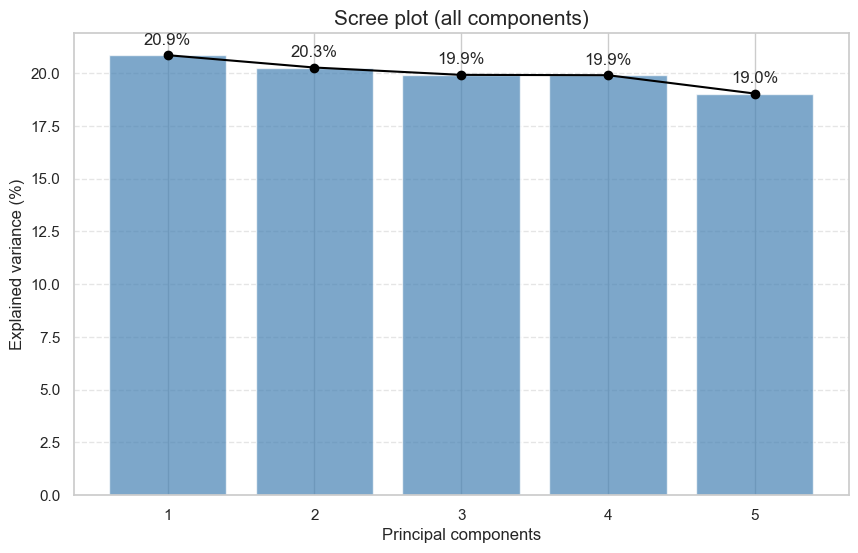

In [48]:
# Quantitative variables
X = df[quantitatives]

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=len(quantitatives))
pca.fit(X_scaled)

# Extraction of the first two components
PCs = pca.transform(X_scaled)
PC1 = PCs[:, 0]
PC2 = PCs[:, 1]
explained = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(10,6))

plt.bar(range(1, len(explained)+1), explained, alpha=0.7, color="steelblue")
plt.plot(range(1, len(explained)+1), explained, marker='o', color='black')

for i, v in enumerate(explained):
    plt.text(i+1, v + 0.5, f"{v:.1f}%", ha='center')

plt.title("Scree plot (all components)", fontsize=15)
plt.xlabel("Principal components")
plt.ylabel("Explained variance (%)")
plt.xticks(range(1, len(explained)+1))
plt.grid(axis='y', linestyle='--', alpha=0.5)
# plt.savefig("Scree.png", dpi=300, bbox_inches='tight')
plt.show()

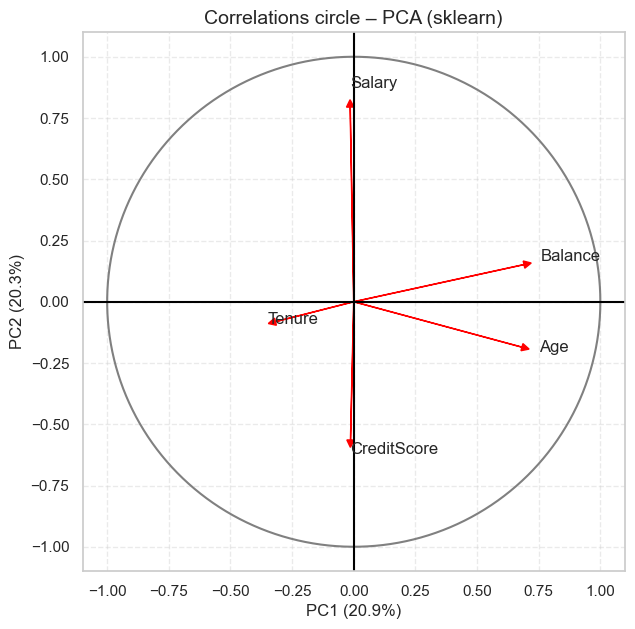

In [49]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

plt.figure(figsize=(7,7))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), color='grey')

plt.axhline(0, color='black')
plt.axvline(0, color='black')

# Vectors
for i, var in enumerate(quantitatives):
    x = loadings[i, 0]
    y = loadings[i, 1]
    plt.arrow(0, 0, x, y, head_width=0.03, head_length=0.03, color='red')
    plt.text(x*1.1, y*1.1, var, fontsize=12)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.title("Correlations circle – PCA (sklearn)", fontsize=14)
plt.xlabel(f"PC1 ({explained[0]:.1f}%)")
plt.ylabel(f"PC2 ({explained[1]:.1f}%)")
plt.grid(ls='--', alpha=0.4)
# plt.savefig("Circle.png", dpi=300, bbox_inches='tight')
plt.show()

In [50]:
results_dim1 = []
results_dim2 = []

for var in quantitatives:
    r1, p1 = pearsonr(df[var], PC1)
    r2, p2 = pearsonr(df[var], PC2)
    results_dim1.append([var, r1, p1])
    results_dim2.append([var, r2, p2])

table_dim1 = pd.DataFrame(results_dim1, columns=["Variable", "Correlation", "p-value"])
table_dim2 = pd.DataFrame(results_dim2, columns=["Variable", "Correlation", "p-value"])

print("### Dimension 1")
display(table_dim1)

print("\n### Dimension 2")
display(table_dim2)

### Dimension 1


,Variable,Correlation,p-value
0,CreditScore,-0.012995,2.451784e-01
1,Tenure,-0.317367,1.175604e-186
2,Balance,0.690352,0.000000e+00
3,Age,0.682049,0.000000e+00
4,Salary,-0.014424,1.970565e-01



### Dimension 2


,Variable,Correlation,p-value
0,CreditScore,-0.564236,0.000000e+00
1,Tenure,-0.081400,3.062605e-13
2,Balance,0.151661,2.256981e-42
3,Age,-0.185332,9.523509e-63
4,Salary,0.794520,0.000000e+00


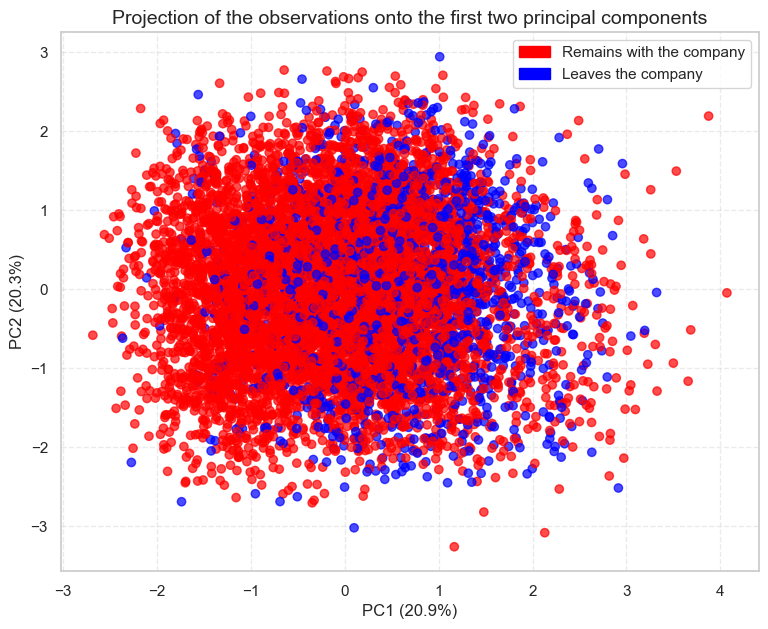

In [51]:
# Projection of the observations
PCs = pca.transform(X_scaled)
PC1 = PCs[:, 0]
PC2 = PCs[:, 1]

# Colors on Churn
colors = df["Churn"].map({0: "red", 1: "blue"})

plt.figure(figsize=(9,7))

# Scatter plot
plt.scatter(PC1, PC2, c=colors, alpha=0.7)
plt.title("Projection of the observations onto the first two principal components", fontsize=14)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(ls="--", alpha=0.4)
legend_items = [
    mpatches.Patch(color='red', label='Remains with the company'),
    mpatches.Patch(color='blue', label='Leaves the company')
]
plt.legend(handles=legend_items, loc='upper right')
# plt.savefig("Projection.png", dpi=300, bbox_inches='tight')
plt.show()